# Light extraction efficiency calculation of a square-shaped µ-LED

**Note: The FC cost of running this notebook is larger than 100 FCs.**

Micro-light-emitting diodes (µ-LEDs) based on InGaN have attracted significant attention as next-generation display technologies, with potential applications ranging from high-resolution panels to augmented and virtual reality systems. As µ-LED dimensions shrink, ensuring high internal quantum efficiency (IQE) and, critically, light extraction efficiency (LEE) becomes increasingly challenging. LEE, in particular, is strongly influenced by structural parameters such as chip cross-sectional geometry, lateral size, and p-GaN thickness.

The finite-difference time-domain (FDTD) method is a powerful tool for predicting and optimizing LEE, allowing systematic evaluation of design variations. These simulations, however, can be very computationally expensive and time-consuming, especially when sweeping a large number of parameters.

Hence, Tidy3D GPU-accelerated solver is the perfect tool to tackle these problems, where large simulations can be handled extremely fast, and in parallel. This makes it possible to complete in just a few hours a workload that would take weeks using other solvers on traditional HPC systems.

In this notebook, we will reproduce some results from the paper by `Han-Youl Ryu, Jeongsang Pyo, and Hyun Yeol Ryu, *"Light Extraction Efficiency of GaN-Based Micro-Scale Light-Emitting Diodes Investigated Using Finite-Difference Time-Domain Simulation,"* IEEE Photonics Journal (2020)`. [DOI:10.1109/JPHOT.2020.2977401](https://ieeexplore.ieee.org/document/9019847). 

First, we will calculate the LEE of a square LED as a function of its cross-sectional size and reflector absorption. Next, we will investigate the relation between LEE and p-GaN layer thickness. Finally, we will verify that, for larger LED sizes, the LEE is well represented by just a single dipole at the center, and that simulating and averaging multiple dipoles at different positions has little effect, greatly reducing computational cost.

<img src="img/squareLED.png" width="500" alt="Schematic of the experiment">

For more information, please refer to our [learning center](https://www.flexcompute.com/tidy3d/examples/), where you can find more examples involving [LEDs](https://www.flexcompute.com/tidy3d/examples/notebooks/BlueMicroLED/) among many other structures.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web

Since the notebook explores many parameter spaces, the cost of running it in full is quite high. For this reason, the global `RUN` parameter is set to `False` by default, to prevent unintentional execution.

In [2]:
RUN = False

## Simulation Setup

First we will define global parameters that will be used in the simulation

In [3]:
# Set logging level to ERROR to avoid too many messages related to long runtimes
td.config.logging.level = "ERROR"

# Operation wavelength and frequency
wl1 = 0.440
wl2 = 0.480

f1 = td.C_0 / wl2
f2 = td.C_0 / wl1

fwidth = (f2 - f1) / 2
freq0 = f1 + fwidth
wl0 = td.C_0 / freq0

source_time = td.GaussianPulse(freq0=freq0, fwidth=fwidth)

# Define heights
nGanHeight = 3
MQWHeight = 0.05
reflectorThickness = 0.5

# Wavelength to monitor LEE
wvl_analysis = np.linspace(0.469, 0.472, 11)
freq_analysis = td.C_0 / wvl_analysis

Next we will define an auxiliary function to create the LED structure. The structure is defined by a stack of p-GaN, InGaN MQW and n-GaN on top of a silver reflector.

In [4]:
def createStructure(pGanHeight=0.1, size=3, GANExtinctionCoef=30):
    """
    Create a layered µ-LED structure.

    Parameters
    ----------
    pGanHeight : float
        Thickness of the p-GaN layer (in µm).
    size : float
        Lateral size of the LED (in µm).
    GANExtinctionCoef : float
        Extinction coefficient of GaN (in cm⁻¹).

    Returns
    -------
    structure : list
        List of Tidy3D Structure objects representing the LED layers.
    z_MQW_center : float
        z-coordinate of the MQW layer center.
    MQWHeight : float
        Thickness of the MQW region (in µm).
    dimensions : tuple
        Overall dimensions of the LED (Lx, Ly, total height).
    """

    L = size

    # Define materials
    reflectorThickness = 0.5
    kGan = GANExtinctionCoef * (wl0 * 10**-4) / (4 * np.pi)
    nGanMedium = td.Medium.from_nk(n=2.45, k=kGan, freq=freq0)
    MQWMedium = td.Medium.from_nk(n=2.49, k=0, freq=freq0)
    pGanMedium = td.Medium.from_nk(n=2.45, k=kGan, freq=freq0)
    reflectorMedium = td.Lorentz.from_nk(n=0.14, k=2.47, freq=freq0)

    # Compute z centers
    z_reflector_center = reflectorThickness / 2
    z_pGan_center = reflectorThickness + pGanHeight / 2
    z_MQW_center = reflectorThickness + pGanHeight + MQWHeight / 2
    z_nGan_center = reflectorThickness + pGanHeight + MQWHeight + nGanHeight / 2

    reflector_box = td.Box(
        center=(0, 0, z_reflector_center - 50), size=(10 * L, 10 * L, reflectorThickness + 100)
    )
    pGan_box = td.Box(center=(0, 0, z_pGan_center), size=(L, L, pGanHeight))
    MQW_box = td.Box(center=(0, 0, z_MQW_center), size=(L, L, MQWHeight))
    nGan_box = td.Box(center=(0, 0, z_nGan_center), size=(L, L, nGanHeight))

    # Create structure list with materials
    structure = [
        td.Structure(geometry=reflector_box, medium=reflectorMedium, name="reflector"),
        td.Structure(geometry=pGan_box, medium=pGanMedium, name="pGan"),
        td.Structure(geometry=MQW_box, medium=MQWMedium, name="MQW"),
        td.Structure(geometry=nGan_box, medium=nGanMedium, name="nGan"),
    ]

    total_height = reflectorThickness + pGanHeight + MQWHeight + nGanHeight

    return structure, z_MQW_center, MQWHeight, (L, L, total_height)

Next, we will define a function to return the [Simulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html) object. The source is a [PointDipole](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PointDipole.html). We will add a normalization monitor at the MQW to record the emitted power, along with two other [FluxMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FluxMonitor.html)s to record the total extracted power and the extracted power in the z+ direction.

We will also define an auxiliary function to automatically set the appropriate symmetry when applicable, based on the source position.

Since some µ-LEDs can be relatively large, and the fields can remain confined inside the structure for a long time, we will increase the [shutoff](https://www.flexcompute.com/tidy3d/learning-center/tidy3d-gui/Lecture-8-Run-Time-and-Shutoff/) parameter from the default value of 1e-5 to 1e-4.


In [5]:
def parseSymmetry(geometrySymmetry, polarization, posx, posy=0):
    """Parse geometry symmetry and polarization to set Tidy3D symmetry flags.

    Parameters
    ----------
    geometrySymmetry : tuple of bool
        Symmetry along (x, y, z) axes.
    polarization : str
        Dipole polarization ("Ex", "Ey", or "Ez").
    posx : float
        x-position of the source (µm).
    posy : float, optional
        y-position of the source (µm), default is 0.

    Returns
    -------
    list of int
        Symmetry settings for (x, y, z), with 0 for none, ±1 for symmetry/antisymmetry.
    """

    if polarization == "Ex":
        sym = (-1 if geometrySymmetry[0] else 0, 1 if geometrySymmetry[1] else 0, 0)
    elif polarization == "Ey":
        sym = (1 if geometrySymmetry[0] else 0, -1 if geometrySymmetry[1] else 0, 0)
    elif polarization == "Ez":
        sym = (1 if geometrySymmetry[0] else 0, 1 if geometrySymmetry[1] else 0, 0)

    return [sym[0] if posx == 0 else 0, sym[1] if posy == 0 else 0, 0]

In [6]:
def getSim(
    pGanHeight=0.1,
    size=20,
    pad=1,
    padz=1,
    min_steps_per_wvl=12,
    GANExtinctionCoef=30,
    background_medium=td.Medium.from_nk(n=1.5, k=0, freq=freq0),
    source_position=(0, 0),
    polarization="Ex",
    symmetry=(1, 1, 0),
):
    """Build a Tidy3D simulation of a square µ-LED with dipole excitation.

    Parameters
    ----------
    pGanHeight : float
        Thickness of the p-GaN layer (µm).
    size : float
        Lateral size of the LED (µm).
    pad : float
        Padding in x and y directions (µm).
    padz : float
        Padding in z direction (µm).
    min_steps_per_wvl : int
        Minimum grid steps per wavelength.
    GANExtinctionCoef : float
        Extinction coefficient of GaN (cm⁻¹).
    background_medium : td.Medium
        Background medium of the simulation.
    source_position : tuple
        (x, y) position of the dipole source (µm).
    polarization : str
        Dipole polarization ("Ex", "Ey", or "Ez").
    symmetry : tuple
        Symmetry settings for the simulation.

    Returns
    -------
    td.Simulation
        Configured Tidy3D simulation with structures, source, and monitors.
    """

    structures, QWCenter, QWHeight, structure_size = createStructure(
        pGanHeight=pGanHeight, size=size, GANExtinctionCoef=GANExtinctionCoef
    )

    x, y = source_position
    zPosition = QWCenter
    dipole = td.PointDipole(
        center=(x, y, zPosition),
        polarization=polarization,
        source_time=source_time,
        name=f"dipole_{x}_{y}_{polarization}",
    )

    symmetry = parseSymmetry(symmetry, polarization, x, y)

    grid_spec = td.GridSpec.auto(min_steps_per_wvl=min_steps_per_wvl, wavelength=wl1)

    boundary_spec = td.BoundarySpec(
        x=td.Boundary(minus=td.PML(), plus=td.PML()),
        y=td.Boundary(minus=td.PML(), plus=td.PML()),
        z=td.Boundary(minus=td.Absorber(), plus=td.PML()),
    )

    sim_size = [i + 2 * pad for i in structure_size[:2]] + [2 * padz + structure_size[2]]
    sim_center = [0, 0, structure_size[2] / 2 + padz]

    # Monitors

    norm_flux_monitor = td.FluxMonitor(
        center=structures[2].geometry.center,
        size=structures[2].geometry.size,
        name="norm_flux_monitor",
        freqs=freq_analysis,
    )

    outside_flux_monitor = td.FluxMonitor(
        center=(sim_center[0], sim_center[1], sim_center[2] - pad / 2),
        size=[sim_size[0] - pad, sim_size[1] - pad, sim_size[2] - pad / 2],
        freqs=norm_flux_monitor.freqs,
        name="outside_flux_monitor",
        exclude_surfaces=["z-"],
    )

    lateral_flux_monitor = td.FluxMonitor(
        center=(sim_center[0], sim_center[1], sim_center[2] - pad / 2),
        size=[sim_size[0] - pad, sim_size[1] - pad, sim_size[2] - pad / 2],
        freqs=norm_flux_monitor.freqs,
        name="lateral_flux_monitor",
        exclude_surfaces=["z-", "z+"],
    )

    sim = td.Simulation(
        size=sim_size,
        center=sim_center,
        grid_spec=grid_spec,
        structures=structures,
        sources=[dipole],
        monitors=[norm_flux_monitor, outside_flux_monitor, lateral_flux_monitor],
        run_time=20e-12,
        boundary_spec=boundary_spec,
        medium=background_medium,
        symmetry=symmetry,
        shutoff=1e-4,
    )

    return sim

Now we can plot and inspect the geometry.

In [7]:
sim = getSim()
sim.plot_3d()

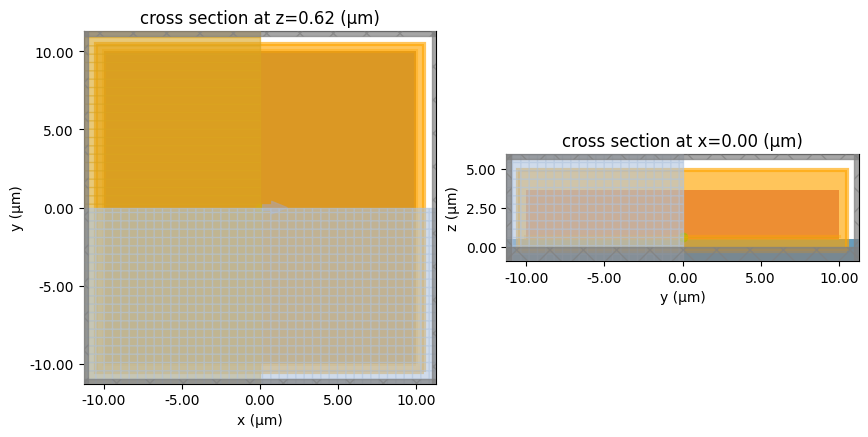

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sim.plot(z=sim.structures[2].geometry.center[2], ax=ax[0])
sim.plot(x=0, ax=ax[1])
plt.show()

Finally, we will define a function for calculating the LEE

In [9]:
def calculateLEE(sim_data, monitor_name="outside_flux_monitor"):
    fluxDipole = sim_data["norm_flux_monitor"].flux
    fluxOutside = sim_data[monitor_name].flux

    return np.mean(fluxOutside / fluxDipole)

## LEE as a Function of Length and Reflector Absorption

First, we will investigate the relation between the LEE, the device size, and the reflector absorption coefficient. We will create a [Batch](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.web.api.container.Batch.html) object to run the simulations in parallel. Before running, we can also estimate the maximum cost of the batch.

In [10]:
sizes = [1, 5, 15, 30]
abs = [0, 10, 30, 50]
sims_varying_abs = {}
for l in sizes:
    for a in abs:
        sims_varying_abs[str((l, a))] = getSim(size=l, GANExtinctionCoef=a)


batch_varying_abs = web.Batch(simulations=sims_varying_abs, folder_name="LedLEECalculation")
batch_varying_abs.estimate_cost();

16:53:31 -03 Maximum FlexCredit cost: 354.029 for the whole batch.

Next, we run the batch.

In [11]:
if RUN:
    batch_data_varying_abs = batch_varying_abs.run(path_dir="varying_abs")

Output()

We can now verify the effective cost of the batch. Since some simulations ended before the stipulated runtime, the actual cost is smaller than the estimated maximum.

In [12]:
batch_varying_abs.real_cost();

16:53:44 -03 Total billed flex credit cost: 232.624.

Post-processing the data.

In [13]:
import pandas as pd

df = pd.DataFrame()

for k in batch_data_varying_abs.keys():
    tup = eval(k)
    abs = float(tup[1])
    l = float(tup[0])

    sim_data = batch_data_varying_abs[k]
    lee = calculateLEE(sim_data)
    df.loc[abs, l] = lee.values

As we can see, the LEE decreases with both the LED cross-section size and the reflector absorption.

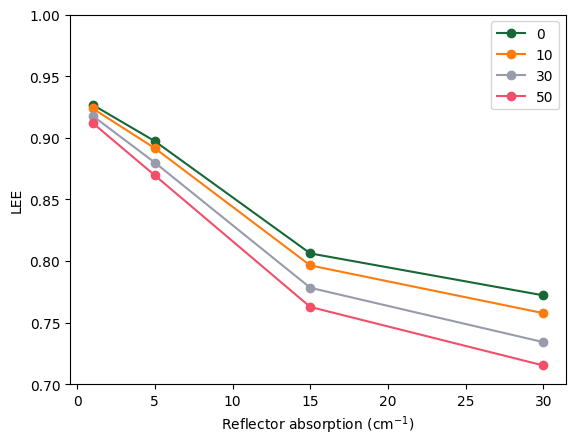

In [14]:
fig, ax = plt.subplots()

ax.set_xlabel("Reflector absorption (cm$^{-1}$)")
ax.set_ylabel("LEE")

df.T.plot(ax=ax, marker="o")
ax.set_ylim(0.7, 1)
plt.show()

## LEE as a Function of p-GaN Thickness

Next, we will investigate the influence of the p-GaN layer thickness for LEDs of sizes 5, 10 and 20 µm

In [15]:
pGanHeights = np.linspace(0.060, 0.140, 9)

sims_varyingpGan_L5 = {}
sims_varyingpGan_L10 = {}
sims_varyingpGan_L20 = {}

for p in pGanHeights:
    sim_L5 = getSim(pGanHeight=p, size=5)
    sims_varyingpGan_L5[str(p)] = sim_L5

    sim_L10 = getSim(pGanHeight=p, size=10)
    sims_varyingpGan_L10[str(p)] = sim_L10

    sim_L20 = getSim(pGanHeight=p, size=20)
    sims_varyingpGan_L20[str(p)] = sim_L20


batch_varyingpGan_L5 = web.Batch(simulations=sims_varyingpGan_L5, folder_name="LEECalculation")
batch_varyingpGan_L10 = web.Batch(simulations=sims_varyingpGan_L10, folder_name="LEECalculation")
batch_varyingpGan_L20 = web.Batch(simulations=sims_varyingpGan_L20, folder_name="LEECalculation")

In [16]:
if RUN:
    batch_data_varyingpGan_L5 = batch_varyingpGan_L5.run(path_dir="varyingpGan_L5")
    batch_data_varyingpGan_L10 = batch_varyingpGan_L10.run(path_dir="varyingpGan_L10")
    batch_data_varyingpGan_L20 = batch_varyingpGan_L20.run(path_dir="varyingpGan_L20")

Output()

Output()

Output()

In [17]:
Lee_varyingpGan_L5 = []
Lee_varyingpGan_L10 = []
Lee_varyingpGan_L20 = []

for p in pGanHeights:
    sim_data_L5 = batch_data_varyingpGan_L5[str(p)]
    Lee_varyingpGan_L5.append(calculateLEE(sim_data_L5))

    sim_data_l10 = batch_data_varyingpGan_L10[str(p)]
    Lee_varyingpGan_L10.append(calculateLEE(sim_data_l10))

    sim_data_l20 = batch_data_varyingpGan_L20[str(p)]
    Lee_varyingpGan_L20.append(calculateLEE(sim_data_l20))

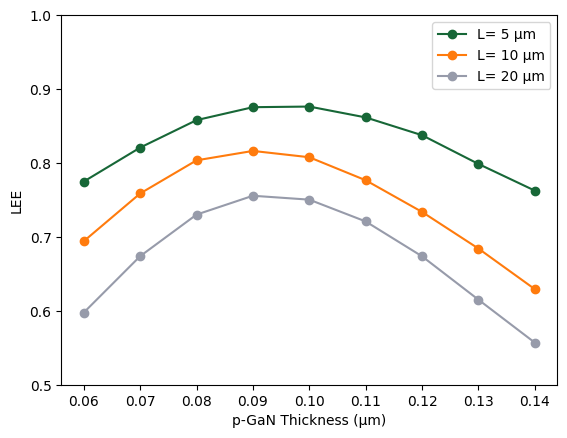

In [18]:
fig, ax = plt.subplots()
ax.plot(pGanHeights, Lee_varyingpGan_L5, "o-", label="L= 5 µm")
ax.plot(pGanHeights, Lee_varyingpGan_L10, "o-", label="L= 10 µm")
ax.plot(pGanHeights, Lee_varyingpGan_L20, "o-", label="L= 20 µm")
ax.set_xlabel("pGan Heights")
ax.set_ylabel("LEE")
ax.legend()


ax.set_ylim(0.5, 1)

ax.set_xlabel("p-GaN Thickness (µm)")
ax.set_ylabel("LEE")
plt.show()

We can also decompose the total LEE into its lateral and vertical components. The results match well the ones presented on the Fig. 6 of the reference [paper](https://ieeexplore.ieee.org/document/9019847)

In [19]:
Lee_varyingpGan_L20_lateral = []
Lee_varyingpGan_L20 = []
for p in pGanHeights:
    sim_data_l20 = batch_data_varyingpGan_L20[str(p)]
    Lee_varyingpGan_L20.append(calculateLEE(sim_data_l20))
    Lee_varyingpGan_L20_lateral.append(
        calculateLEE(sim_data_l20, monitor_name="lateral_flux_monitor")
    )

Lee_varyingpGan_L20_top = np.array(Lee_varyingpGan_L20) - np.array(Lee_varyingpGan_L20_lateral)

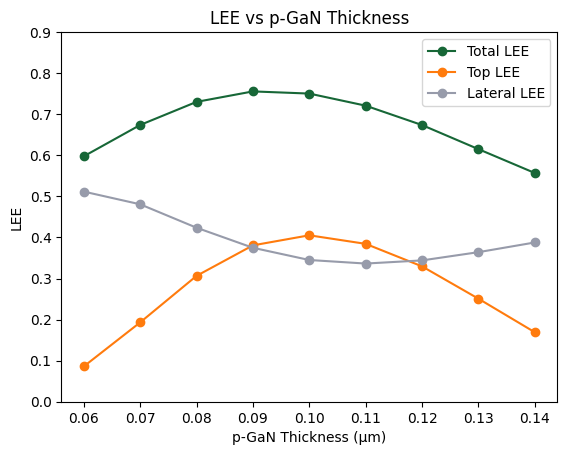

In [20]:
fig, ax = plt.subplots()

ax.plot(pGanHeights, Lee_varyingpGan_L20, "o-", label="Total LEE")
ax.plot(pGanHeights, Lee_varyingpGan_L20_top, "o-", label="Top LEE")
ax.plot(pGanHeights, Lee_varyingpGan_L20_lateral, "o-", label="Lateral LEE")

ax.set_xlabel("p-GaN Thickness (µm)")
ax.set_ylabel("LEE")

ax.legend()
plt.title("LEE vs p-GaN Thickness")
ax.set_ylim(0, 0.9)
plt.show()

## Relative Error for Single Dipole LEE Calculation

Now, we will run batch simulations with distributed dipoles to calculate the average LEE value and compare the results with those from a single dipole at the center, to estimate how accurate the single dipole approximation is.

We will define a function to calculate the mean LEE by exploiting the rotational and mirror symmetries of the structure. The `lee_dict` is a dictionary mapping each dipole position to its corresponding LEE. The function ensures the correct contributions are included (e.g., a dipole at (1,1) has the same LEE contribution as (-1,1), (-1,-1), and (1,-1)).

In [21]:
def averageLee(lee_dict):
    """Compute the average LEE using rotational and mirror symmetries.

    Parameters
    ----------
    lee_dict : dict
        Dictionary mapping dipole position keys (e.g., 'dipole_x_y')
        to their corresponding LEE values.

    Returns
    -------
    np.ndarray
        Symmetry-averaged LEE.
    """

    avg_lee = 0
    count = 0

    for key, values in lee_dict.items():
        posX, posY = key.split("_")[1:3]
        posX, posY = float(posX), float(posY)

        # Case 1: source at center -> counts once
        if (posX == 0) and (posY == 0):
            avg_lee += np.array(values)
            count += 1

        # Case 2: source on x- or y-axis -> symmetric copy doubles contribution
        elif posY == 0:
            avg_lee += 2 * np.array(values)
            count += 2

        elif posX == 0:
            avg_lee += 2 * np.array(values)
            count += 2

        # Case 3: source off axes -> four symmetric positions
        else:
            avg_lee += 4 * np.array(values)
            count += 4

    return avg_lee / count


def calculateLees(Total_lee, batch_data):
    """Calculate the center LEE and the symmetry-averaged LEE.

    Parameters
    ----------
    Total_lee : list
        List of LEE values for all dipole positions.
    batch_data : dict
        Dictionary mapping position keys to dipole metadata.

    Returns
    -------
    tuple
        - center_lee : float
            Mean LEE at the center dipole.
        - avgLee : np.ndarray
            Symmetry-averaged LEE across all dipoles.
    """

    center_lee = Total_lee[0]

    lee_dict = {key: Total_lee[i] for i, key in enumerate(batch_data.keys())}
    avgLee = averageLee(lee_dict)

    return float(np.mean(center_lee)), avgLee

Next, we define a function to create a batch by placing the dipoles in a grid around the LED. Since we can use mirror and rotational symmetries, the dipoles only need to be placed in a quarter of the MQW area.

In [22]:
def createSingleDipoleBatch(
    simBase,
    source_time,
    dipoles_per_dimension=5,
    xSpan=(0, 1),
    polarization="inplane",  # inplane or outofplane
    symmetry=(1, 1, 0),
):
    """Create a batch of simulations with dipoles placed across the LED structure.

    Parameters
    ----------
    simBase : td.Simulation
        Base LED simulation.
    source_time : td.SourceTime
        Time profile of the dipole source.
    dipoles_per_dimension : int, optional
        Number of dipole positions sampled per dimension (default=5).
    xSpan : tuple of float, optional
        Range of x positions for dipoles (µm), default is (0, 1).
    polarization : str, optional
        Polarization of dipoles: "inplane" (Ex) or "outofplane" (Ez).
    symmetry : tuple, optional
        Symmetry settings for the simulation (default=(1,1,0)).

    Returns
    -------
    dict
        Dictionary mapping keys (format: 'pol_x_y_index') to Tidy3D Simulation objects.
    """

    sims = {}

    x = np.linspace(xSpan[0], xSpan[1], dipoles_per_dimension)
    for i in range(dipoles_per_dimension):
        y = x[i]

        if polarization == "outofplane":
            pol = "Ez"
            xList = x[i:]
        elif polarization == "inplane":
            pol = "Ex"
            xList = x
        else:
            pol = polarization
            xList = x[i:] if polarization == "Ez" else x

        for pos in xList:
            zPosition = simBase.sources[0].center[2]
            dipole = td.PointDipole(
                center=(pos, y, zPosition),
                polarization=pol,
                source_time=source_time,
                name=f"dipole_{x}_{y}_{polarization}",
            )

            sim = simBase.updated_copy(
                sources=[dipole], symmetry=parseSymmetry(symmetry, pol, pos, y)
            )

            sims[f"{pol}_{pos}_{y}_{i}"] = sim

    print("Number of Simulations:", len(sims))

    return sims

Now we can create the batch simulation for different LED sizes.

In [23]:
simBase = getSim(size=1)
sims_l1 = createSingleDipoleBatch(
    simBase,
    source_time=source_time,
    dipoles_per_dimension=4,
    xSpan=(0, 0.4),
    polarization="inplane",
    symmetry=(1, 1, 0),
)
batch_l1 = web.Batch(simulations=sims_l1, folder_name="LED")

simBase = getSim(size=2.5)
sims_l2d5 = createSingleDipoleBatch(
    simBase,
    source_time=source_time,
    dipoles_per_dimension=4,
    xSpan=(0, 0.9 * 2.5 / 2),
    polarization="inplane",
    symmetry=(1, 1, 0),
)
batch_l2d5 = web.Batch(simulations=sims_l2d5, folder_name="LED")

simBase = getSim(size=3)
sims_l3 = createSingleDipoleBatch(
    simBase,
    source_time=source_time,
    dipoles_per_dimension=4,
    xSpan=(0, 0.9 * 3 / 2),
    polarization="inplane",
    symmetry=(1, 1, 0),
)
batch_l3 = web.Batch(simulations=sims_l3, folder_name="LED")


simBase = getSim(size=5)
sims_l5 = createSingleDipoleBatch(
    simBase,
    source_time=source_time,
    dipoles_per_dimension=3,
    xSpan=(0, 2),
    polarization="inplane",
    symmetry=(1, 1, 0),
)

batch_l5 = web.Batch(simulations=sims_l5, folder_name="LED")


simBase = getSim(size=10)
sims_l10 = createSingleDipoleBatch(
    simBase,
    source_time=source_time,
    dipoles_per_dimension=3,
    xSpan=(0, 0.9 * 10 / 2),
    polarization="inplane",
    symmetry=(1, 1, 0),
)
batch_l10 = web.Batch(simulations=sims_l10, folder_name="LED")

simBase = getSim(size=20)
sims_l20 = createSingleDipoleBatch(
    simBase,
    source_time=source_time,
    dipoles_per_dimension=3,
    xSpan=(0, 0.9 * 20 / 2),
    polarization="inplane",
    symmetry=(1, 1, 0),
)
batch_l20 = web.Batch(simulations=sims_l20, folder_name="LED")

Number of Simulations: 16
Number of Simulations: 16
Number of Simulations: 16
Number of Simulations: 9
Number of Simulations: 9
Number of Simulations: 9


We can define a function to plot all the sources of a given batch together for inspection.

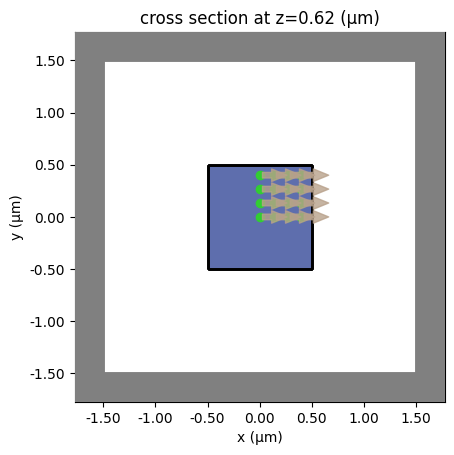

In [24]:
def plot_batch(batch, **args):
    """Function for visualize all sources for a given batch"""
    fig, ax = plt.subplots()
    sims = list(batch.simulations.values())
    z = sims[0].sources[0].center[2]
    sims[0].updated_copy(symmetry=[0, 0, 0]).plot(z=z, ax=ax, monitor_alpha=0)
    for sim in sims[1:]:
        sim.updated_copy(symmetry=[0, 0, 0]).plot(
            z=z, ax=ax, monitor_alpha=0, fill_structures=False
        )
    plt.show()


plot_batch(batch_l1)

In [25]:
if RUN:
    batch_l1_data = batch_l1.run(path_dir="MultipleDipolesL1Ex")
    batch_l2d5_data = batch_l2d5.run(path_dir="MultipleDipolesL2d5Ex")
    batch_l5_data = batch_l5.run(path_dir="MultipleDipolesL5Ex")
    batch_l10_data = batch_l10.run(path_dir="MultipleDipolesL10Ex")
    batch_l20_data = batch_l20.run(path_dir="MultipleDipolesL20Ex")

Output()

Output()

Output()

Output()

Output()

Output()

In [26]:
Total_lee1 = [calculateLEE(sim_data) for sim_data in batch_l1_data.values()]
Total_lee2d5 = [calculateLEE(sim_data) for sim_data in batch_l2d5_data.values()]
Total_lee5 = [calculateLEE(sim_data) for sim_data in batch_l5_data.values()]
Total_lee10 = [calculateLEE(sim_data) for sim_data in batch_l10_data.values()]
Total_lee20 = [calculateLEE(sim_data) for sim_data in batch_l20_data.values()]

As we can see, the error in the single dipole approximation tends to decrease with size. Hence, using only a dipole at the center can greatly reduce computational cost while still providing accurate results.

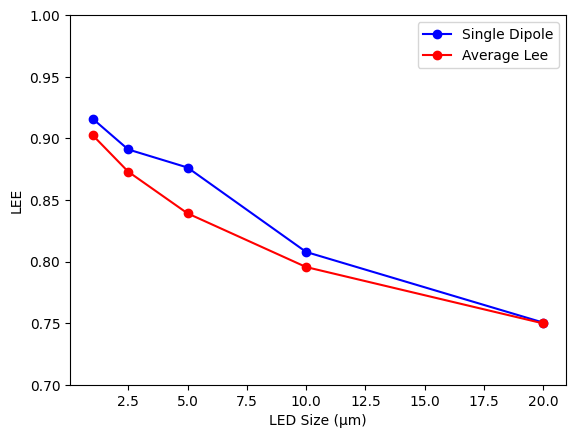

In [27]:
fig, ax = plt.subplots()

size = [1, 2.5, 5, 10, 20]
lee0 = []
avgLee = []

center, avg = calculateLees(Total_lee1, batch_l1_data)
lee0.append(center)
avgLee.append(avg)

center, avg = calculateLees(Total_lee2d5, batch_l2d5_data)
lee0.append(center)
avgLee.append(avg)


center, avg = calculateLees(Total_lee5, batch_l5_data)
lee0.append(center)
avgLee.append(avg)

center, avg = calculateLees(Total_lee10, batch_l10_data)
lee0.append(center)
avgLee.append(avg)

center, avg = calculateLees(Total_lee20, batch_l20_data)
lee0.append(center)
avgLee.append(avg)

ax.plot(size, lee0, "o-", color="blue", label="Single Dipole")
ax.plot(size, avgLee, "o-", color="red", label="Average Lee")

ax.set_ylim(0.7, 1)
ax.set_xlabel("LED Size (µm)")
ax.set_ylabel("LEE")
plt.legend()
plt.show()